In [ ]:
%load_ext autoreload
%autoreload 2

# Eva Data

This notebook builds a `MultiDataset` containing exactly one `ZarrDataset`, loads one batch, visualizes one image with `mediapy`, and prints the rest of the batch.

In [ ]:
from pathlib import Path

import cv2
import imageio_ffmpeg
import mediapy as mpy
import numpy as np
import torch

from egomimic.rldb.embodiment.eva import Eva
from egomimic.rldb.embodiment.human import Aria
from egomimic.rldb.zarr.zarr_dataset_multi import MultiDataset, ZarrDataset
from egomimic.rldb.zarr.zarr_dataset_multi import S3EpisodeResolver
from egomimic.rldb.filters import DatasetFilter
from egomimic.utils.egomimicUtils import (
    INTRINSICS,
    cam_frame_to_cam_pixels,
    nds,
)
from egomimic.utils.aws.aws_data_utils import load_env

# Ensure mediapy can find an ffmpeg executable in this environment
mpy.set_ffmpeg(imageio_ffmpeg.get_ffmpeg_exe())

In [ ]:
TEMP_DIR = "/coc/flash7/scratch/egoverseS3ZarrDataset/" # replace with your own temp directory for caching S3 data
load_env()

In [ ]:
key_map = Eva.get_keymap()
transform_list = Eva.get_transform_list()

resolver = S3EpisodeResolver(
    TEMP_DIR, key_map=key_map, transform_list=transform_list
)
filters = DatasetFilter(
    filter_lambdas=[
        "lambda row: row['episode_hash'] in {'2026-01-03-02-16-02-519000'}"
    ]
)
multi_ds = MultiDataset._from_resolver(
    resolver, filters=filters, sync_from_s3=True, mode="total"
)

loader = torch.utils.data.DataLoader(multi_ds, batch_size=1, shuffle=False)

In [ ]:
# Separate YPR visualization preview
for batch in loader:
    vis_ypr = Eva.viz_transformed_batch(batch, mode="axes")
    mpy.show_image(vis_ypr)
    break

In [ ]:
images = []
for i, batch in enumerate(loader):
    vis = Eva.viz_transformed_batch(batch, mode="traj+rotation")
    images.append(vis)
    if i > 10:
        break

mpy.show_video(images, fps=30)

## Human Datasets
Mecka, Scale and Aria all use different key_maps 

In [ ]:
intrinsics_key = "base"

key_map = Aria.get_keymap(mode="cartesian")
transform_list = Aria.get_transform_list(mode="cartesian")

resolver = S3EpisodeResolver(
    TEMP_DIR,
    key_map=key_map,
    transform_list=transform_list,
)

filters = DatasetFilter(
    filter_lambdas=[
        "lambda row: row['episode_hash'] in {'2025-10-29-22-06-00-425000'}"
        # "lambda row: row['episode_hash'] in {'692ee048ef7557106e6c4b8d'}" mecka
    ]
)


cloudflare_ds = MultiDataset._from_resolver(
    resolver, filters=filters, sync_from_s3=True, mode="total"
)

loader = torch.utils.data.DataLoader(cloudflare_ds, batch_size=1, shuffle=False)

In [ ]:
ims = []
for i, batch in enumerate(loader):
    vis = Aria.viz_transformed_batch(batch, mode="traj")
    ims.append(vis)
    # mpy.show_image(vis)

    # for k, v in batch.items():
    #     print(f"{k}: {tuple(v.shape)}")
    
    if i > 10:
        break

mpy.show_video(ims, fps=30)


In [ ]:
# Aria YPR video (same data loop, YPR overlay)
ims_ypr = []
for i, batch in enumerate(loader):
    vis_ypr = Aria.viz_transformed_batch(batch, mode="axes")
    ims_ypr.append(vis_ypr)
    if i > 20:
        break

mpy.show_video(ims_ypr, fps=30)

In [ ]:
key_map = Aria.get_keymap(mode="keypoints")
transform_list = Aria.get_transform_list(mode="keypoints_headframe_ypr")

resolver = S3EpisodeResolver(
    TEMP_DIR,
    key_map=key_map,
    transform_list=transform_list,
)

cloudflare_ds = MultiDataset._from_resolver(
    resolver, filters=filters, sync_from_s3=True, mode="total"
)

loader = torch.utils.data.DataLoader(cloudflare_ds, batch_size=1, shuffle=False)

In [ ]:
from egomimic.rldb.embodiment.human import _build_aria_keypoints_revert_eef_frame_transform_list
ims_keypoints = []
revert_transform_list = _build_aria_keypoints_revert_eef_frame_transform_list(is_quat=False)
for i, batch in enumerate(loader):
    vis_keypoints = Aria.viz_transformed_batch(batch, mode="keypoints", viz_batch_key="actions_keypoints")
    ims_keypoints.append(vis_keypoints)
    if i > 20:
        break

mpy.show_video(ims_keypoints, fps=30)

## Aria Gaze

In [ ]:
from egomimic.utils.egomimicUtils import INTRINSICS, cam_frame_to_cam_pixels, draw_dot_on_frame, get_gaze_endpoint, ARIA_T_RGB_CPF
from egomimic.rldb.zarr.zarr_dataset_multi import MultiDataset, ZarrDataset
import mediapy as mpy
import numpy as np
import torch
from pathlib import Path

key_map_gaze = {
    "images.front_1": {"zarr_key": "images.front_1"},
    "eye_gaze": {"zarr_key": "obs_eye_gaze"},
}
intrinsics = INTRINSICS["base"]

filters = DatasetFilter(
    filter_lambdas=[
        "lambda row: row['episode_hash'] in {'2025-11-27-23-14-02-277000'}"
    ]
)

resolver = S3EpisodeResolver(
    TEMP_DIR, key_map=key_map_gaze
)
cloudflare_ds = MultiDataset._from_resolver(
    resolver, filters=filters, sync_from_s3=True, mode="total"
)

loader = torch.utils.data.DataLoader(cloudflare_ds, batch_size=1, shuffle=False)

In [ ]:
ims_gaze = []
for i, batch in enumerate(loader):
    print(batch.keys())
    gaze_data = batch['eye_gaze'][0].numpy() # yaw (rads), pitch (rads), depth (m)
    if gaze_data[0] != -100: # value for no gaze estimate
        gaze_point_xyz = get_gaze_endpoint(gaze_data[0], gaze_data[1], gaze_data[2], ARIA_T_RGB_CPF)
        gaze_point_xyz = np.expand_dims(gaze_point_xyz, 0)
        gaze_point_pixel = cam_frame_to_cam_pixels(gaze_point_xyz, intrinsics)
        frame = batch['images.front_1'][0].permute(1,2,0).numpy() * 255
        vis = draw_dot_on_frame(frame, gaze_point_pixel, show=False)
        ims_gaze.append(vis)
        if i > 30:
            break

In [ ]:
mpy.show_video(ims_gaze, fps=30)

# Annotation Viz

In [ ]:
from egomimic.rldb.embodiment.human import Scale
from egomimic.rldb.filters import DatasetFilter
intrinsics_key = "base"

key_map = Scale.get_keymap(mode="cartesian", annotations=True)
transform_list = None

resolver = S3EpisodeResolver(
    folder_path = "/coc/flash7/scratch/egoverseDebugDatasets/egoverseS3DatasetTest/",
    key_map=key_map,
    transform_list=transform_list,
)

filters = DatasetFilter(
    filter_lambdas=[
        "lambda row: row['episode_hash'] in {'2026-03-16-01-22-26-448000'}"
    ]
)

cloudflare_ds = MultiDataset._from_resolver(
    resolver, filters=filters, sync_from_s3=True, mode="total"
)

loader = torch.utils.data.DataLoader(cloudflare_ds, batch_size=1, shuffle=False)

In [ ]:
batch = next(iter(loader))
batch['annotations']

In [ ]:
ims_annotations = []
for i, batch in enumerate(loader):
    vis = Scale.viz_transformed_batch(batch, mode="annotations", viz_batch_key="annotations")
    ims_annotations.append(vis)
    if i > 10:
        break
mpy.show_video(ims_annotations, fps=30)

# YAM Data

YAM robot episodes are stored as **EVA-schema** zarrs on the `yam_zarr_data` Modal
volume (and registered in the mecka SQL table with `robot_name = "yam_bimanual"`).

This section downloads one example episode, loads it through the **EVA** keymap +
transform using the **YAM camera extrinsics** (`extrinsics_key="yam"`), then projects
the end-effector poses onto `front_img_1` with the **YAM intrinsics**
(`INTRINSICS["yam"]`). If the calibration is correct the projected axes / trajectory
land on the grippers. This is exactly the calibration the `yam_ft_cal` finetunes use.


In [1]:
import subprocess
import tempfile
from pathlib import Path

import torch
import mediapy as mpy
import imageio_ffmpeg

from egomimic.rldb.embodiment.eva import Eva
from egomimic.rldb.zarr.zarr_dataset_multi import MultiDataset, LocalEpisodeResolver
from egomimic.utils.egomimicUtils import INTRINSICS, EXTRINSICS

# Point mediapy at the bundled ffmpeg (needed for mpy.show_video) so this section
# works even when run without the Eva cells above.
mpy.set_ffmpeg(imageio_ffmpeg.get_ffmpeg_exe())

# YAM camera calibration is registered under the "yam" key:
print("INTRINSICS['yam']:\n", INTRINSICS["yam"])
print("EXTRINSICS['yam'] arms:", list(EXTRINSICS["yam"].keys()))


/Users/anikethcheluva/Documents/CS Projects/EgoVerse/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
objc[78275]: Class AVFFrameReceiver is implemented in both /Users/anikethcheluva/Documents/CS Projects/EgoVerse/.venv/lib/python3.11/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1192f03a8) and /Users/anikethcheluva/Documents/CS Projects/EgoVerse/.venv/lib/python3.11/site-packages/av/.dylibs/libavdevice.60.3.100.dylib (0x1300e4760). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[78275]: Class AVFAudioReceiver is implemented in both /Users/anikethcheluva/Documents/CS Projects/EgoVerse/.venv/lib/python3.11/site-packages/cv2/.dylibs/libavdevice.61.3

INTRINSICS['yam']:
 [[250.158072   0.       267.540984   0.      ]
 [  0.       260.017893 152.727273   0.      ]
 [  0.         0.         1.         0.      ]]
EXTRINSICS['yam'] arms: ['left', 'right']


In [2]:
# Download one example YAM episode from the yam_zarr_data Modal volume to a local dir.
# A .zarr is a DIRECTORY: pass the PARENT dir (trailing slash) as the destination;
# modal recreates <parent>/<episode>.zarr inside it. Guard on the root `zarr.json`
# (the complete-download marker) — a bare dir left by a failed earlier attempt would
# otherwise be treated as "already downloaded" and fail to load ("No group found").
import shutil

YAM_EPISODE = "2026-07-02-23-04-15-262000"  # any yam_bimanual episode hash
YAM_LOCAL_DIR = Path(tempfile.gettempdir()) / "yam_example"
YAM_LOCAL_DIR.mkdir(parents=True, exist_ok=True)

dest = YAM_LOCAL_DIR / f"{YAM_EPISODE}.zarr"
if not (dest / "zarr.json").exists():
    if dest.exists():
        shutil.rmtree(dest)  # clear a partial/corrupt copy from an earlier failure
    subprocess.run(
        ["modal", "volume", "get", "--env", "robotics",
         "yam_zarr_data", f"{YAM_EPISODE}.zarr", f"{YAM_LOCAL_DIR}/"],
        check=True,
    )
print("local yam episode:", dest, "| valid:", (dest / "zarr.json").exists())


local yam episode: /var/folders/6q/dlt3c6191j17m82qngr9v4s00000gn/T/yam_example/2026-07-02-23-04-15-262000.zarr | valid: True


In [3]:
# Load through the EVA pipeline with the YAM extrinsics (same wiring as yam_ft_cal).
key_map = Eva.get_keymap(keymap_mode="cartesian")
transform_list = Eva.get_transform_list(mode="cartesian", extrinsics_key="yam")

resolver = LocalEpisodeResolver(
    YAM_LOCAL_DIR, key_map=key_map, transform_list=transform_list,
)
yam_ds = MultiDataset._from_resolver(resolver, mode="total")
loader = torch.utils.data.DataLoader(yam_ds, batch_size=1, shuffle=False)
print("frames in episode:", len(yam_ds))


frames in episode: 323


""

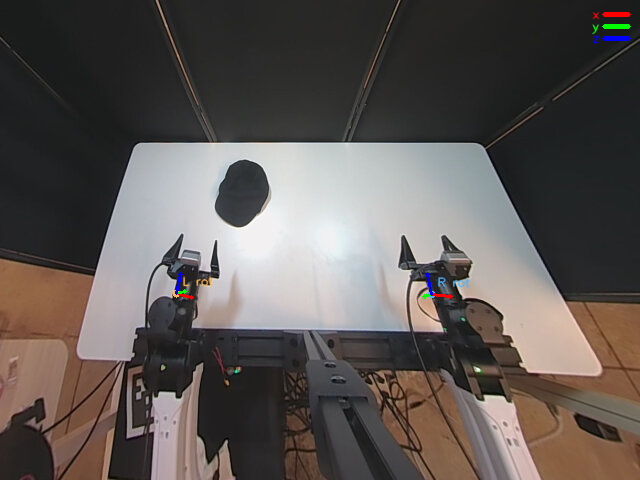

In [4]:
# Project EEF poses onto front_img_1 using the YAM intrinsics (default is "base").
Eva.VIZ_INTRINSICS_KEY = "yam"

for batch in loader:
    vis_axes = Eva.viz_transformed_batch(batch, mode="axes")
    mpy.show_image(vis_axes)
    break


In [5]:
# Trajectory + rotation overlay across the episode.
ims = []
for i, batch in enumerate(loader):
    ims.append(Eva.viz_transformed_batch(batch, mode="traj+rotation"))
    if i > 30:
        break
mpy.show_video(ims, fps=30)


This browser does not support the video tag.
